In [68]:
import numpy as np
import pandas as pd

In [69]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [70]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1258,ham,Honey boo I'm missing u.,NaN,NaN,NaN
4216,ham,Will be office around 4 pm. Now i am going hos...,NaN,NaN,NaN
4781,ham,"Call me, i am senthil from hsbc.",NaN,NaN,NaN
1845,ham,Hi. || Do u want | to join me with sts later? ...,NaN,NaN,NaN
4497,spam,Latest Nokia Mobile or iPOD MP3 Player +å£400 ...,NaN,NaN,NaN
2507,ham,Yup...,NaN,NaN,NaN
1040,ham,Today am going to college so am not able to at...,NaN,NaN,NaN
3468,ham,All day working day:)except saturday and sunday..,NaN,NaN,NaN
2136,ham,Well done and ! luv ya all,NaN,NaN,NaN
956,ham,"Love isn't a decision, it's a feeling. If we c...",NaN,NaN,NaN


In [71]:
df.shape

(5572, 5)


- Data Cleaning
- EDA
- Text Preprocessing
- Model Building
- Evaluation
- Improvements
- Website
- Deploy

DATA CLEANING

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [73]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.sample(5)

,v1,v2
3175,ham,Havent still waitin as usual... ÌÏ come back s...
1885,ham,I think asking for a gym is the excuse for laz...
2900,spam,Ur cash-balance is currently 500 pounds - to m...
273,ham,"Usf I guess, might as well take 1 car"
2415,ham,Huh means computational science... Y they like...


In [74]:
df.rename(columns={'v1' :'target' , 'v2':'text' }, inplace=True)
df.sample(5)


,target,text
1027,ham,Are you not around or just still asleep? :V
1225,ham,"sir, you will receive the account no another 1..."
2799,ham,"House-Maid is the murderer, coz the man was mu..."
4685,ham,But pls dont play in others life.
879,spam,U have a Secret Admirer who is looking 2 make ...


In [75]:
from sklearn.preprocessing import LabelEncoder
encoder =LabelEncoder()

In [76]:
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [77]:
#missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [78]:
df.duplicated().sum()


403

In [79]:
df=df.drop_duplicates(keep='first')

In [80]:
df.duplicated().sum()

0

In [81]:
df.shape

(5169, 2)

Exploratory Data Analysis 


In [82]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [83]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [84]:
import matplotlib.pyplot as plt

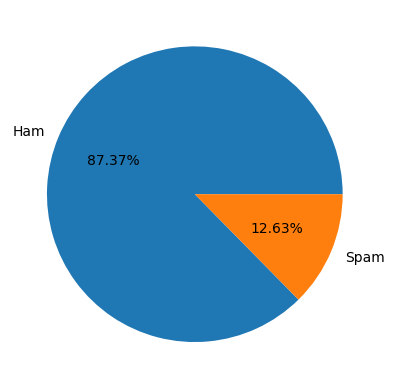

In [85]:

plt.pie(df['target'].value_counts(), labels=['Ham','Spam'], autopct='%0.2f%%')
plt.show()


In [86]:
#Data is imbalanced 
import nltk

In [87]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [88]:
df['num_characters'] =df['text'].apply(len)

In [89]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [90]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [91]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [92]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [93]:
df['text'].apply(lambda x:nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [94]:
df['num_sentences'] =df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [95]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [96]:
df[['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [97]:
#HAM

df[df['target']==0][['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [98]:
#SPAM
df[df['target']==1][['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [99]:
import seaborn as sns

In [100]:
##sns.histplot[df['target']==0]['']

<Axes: xlabel='num_characters', ylabel='Count'>

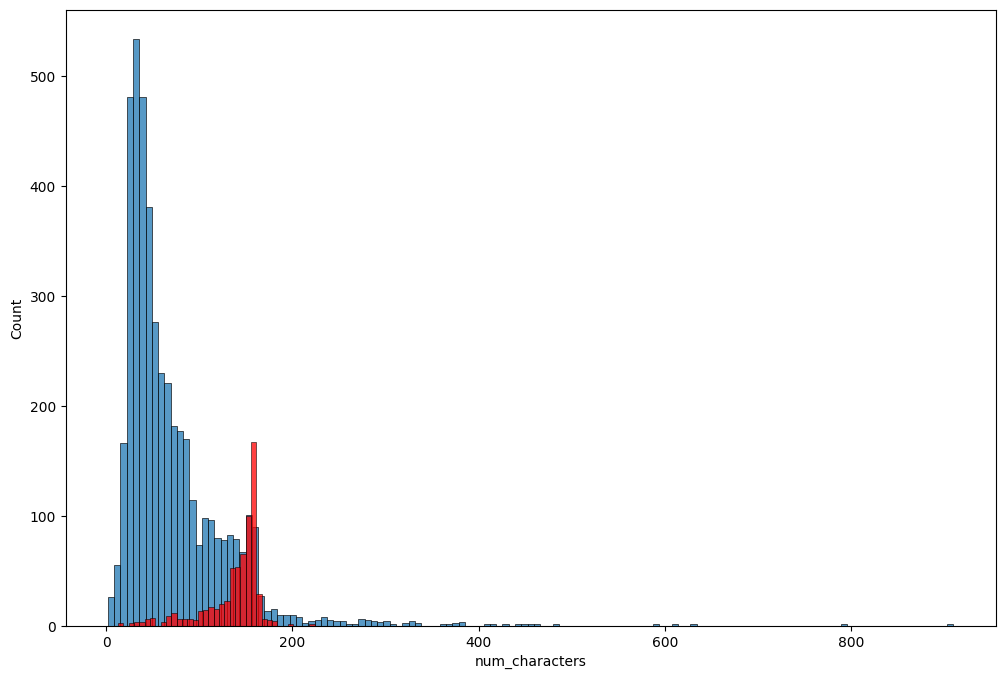

In [101]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'] , color='red')

<Axes: xlabel='num_words', ylabel='Count'>

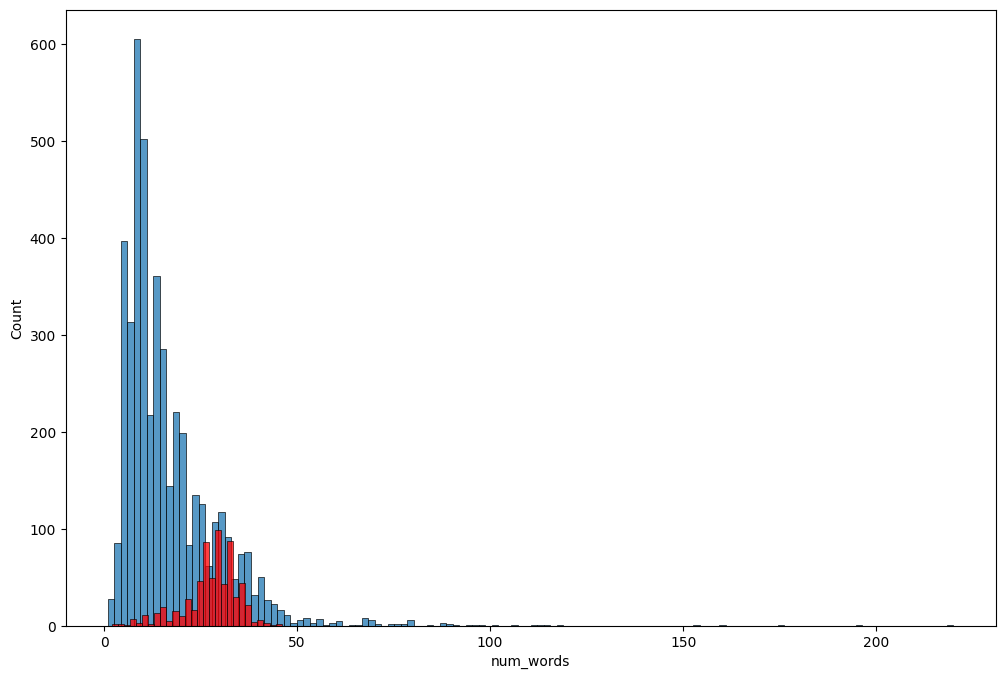

In [102]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'] , color='red')

<Axes: xlabel='num_sentences', ylabel='Count'>

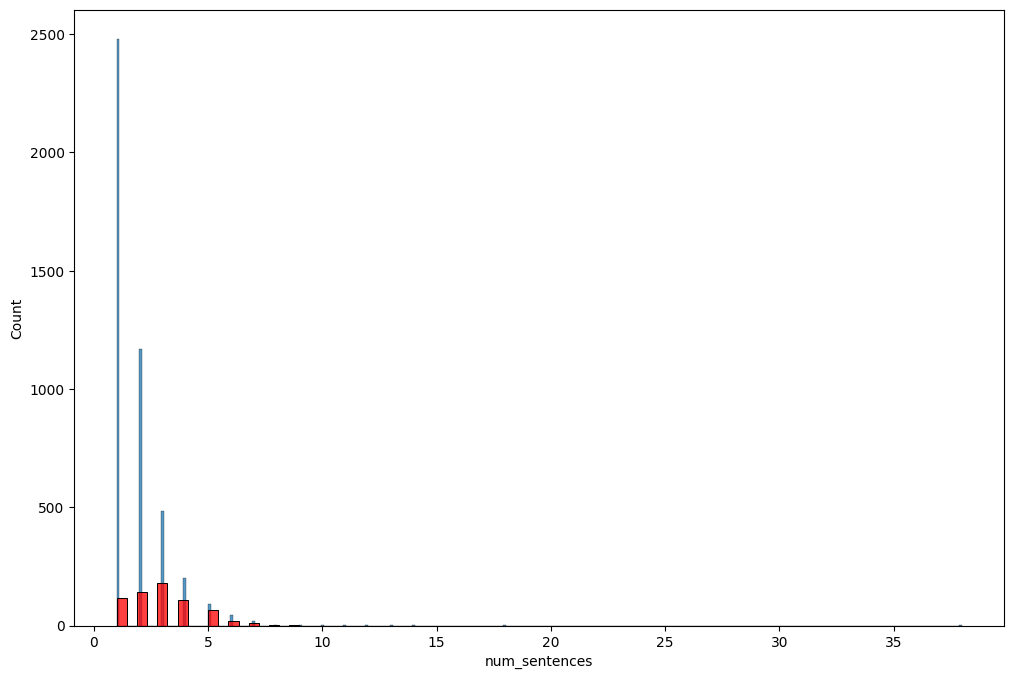

In [103]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_sentences'])
sns.histplot(df[df['target']==1]['num_sentences'] , color='red')

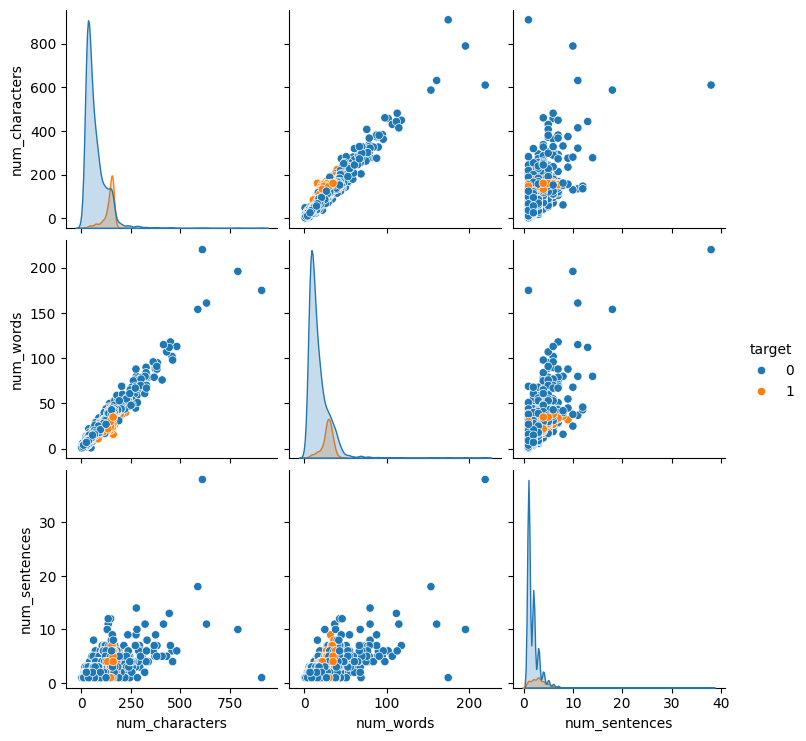

In [104]:
sns.pairplot(df, hue ='target')

<Axes: >

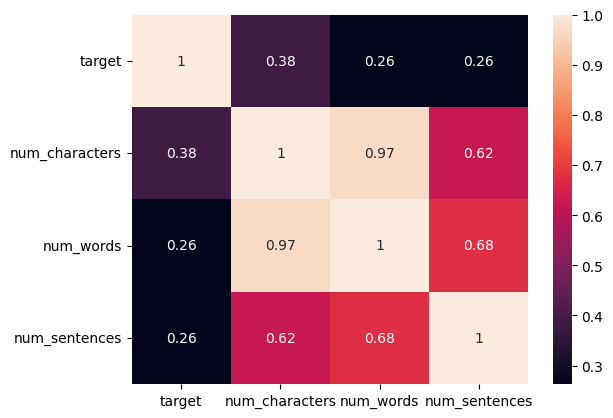

In [105]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming


In [106]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [107]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
   
    text = text.lower()
    
    
    text = nltk.word_tokenize(text)
    
    
    text = [i for i in text if i.isalnum()]
    
    
    text = [i for i in text if i not in stopwords.words('english') 
            and i not in string.punctuation]
    
    text = [ps.stem(i) for i in text]
    

    return " ".join(text)

# Apply to dataframe
df['transformed_text'] = df['text'].apply(transform_text)

# Test
print(df['transformed_text'].head())
print(type(df['transformed_text'][0]))  

0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri 2 wkli comp win fa cup final tkt 21...
3                  u dun say earli hor u c alreadi say
4                 nah think goe usf live around though
Name: transformed_text, dtype: object
<class 'str'>


In [108]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

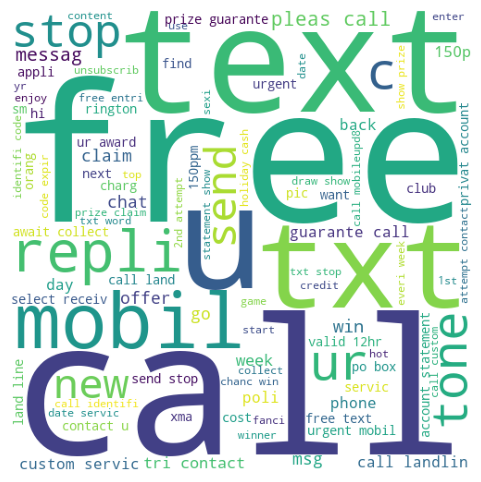

In [109]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, 
               background_color='white')

spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(spam_wc)
plt.axis('off')
plt.show()

In [110]:
from nltk.stem.porter import PorterStemmer
ps= PorterStemmer()
ps.stem('loving')



'love'

In [111]:

df['transformed_text'] = df['text'].apply(transform_text)

In [112]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [113]:
from wordcloud import WordCloud
wc = WordCloud(width =500, height =500, min_font_size=10, background_color='white')

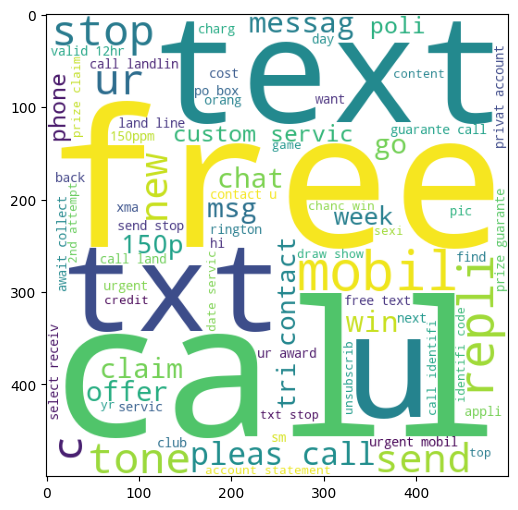

In [114]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(spam_wc)

plt.show()

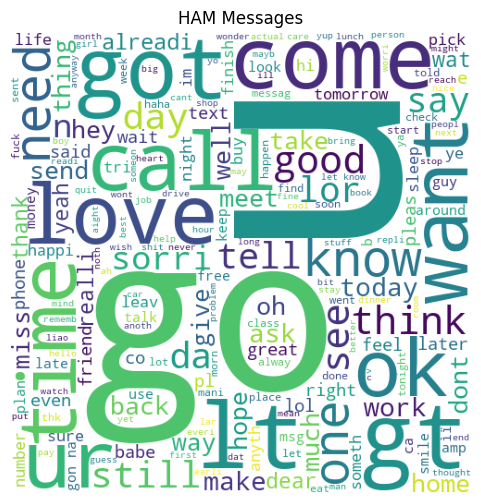

In [115]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(ham_wc)
plt.axis('off')
plt.title("HAM Messages")
plt.show()

In [116]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [117]:

spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [118]:

len(spam_corpus)

9939

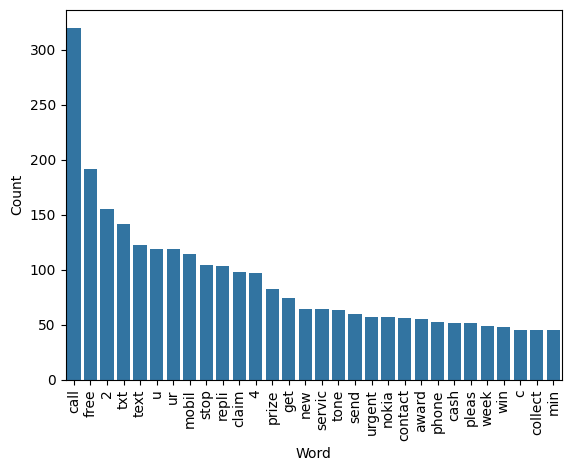

In [119]:
from collections import Counter

spam_df = pd.DataFrame(Counter(spam_corpus).most_common(30), 
                       columns=['Word', 'Count'])

sns.barplot(x='Word', y='Count', data=spam_df)
plt.xticks(rotation='vertical')
plt.show()

In [120]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [121]:
len(ham_corpus)

35404

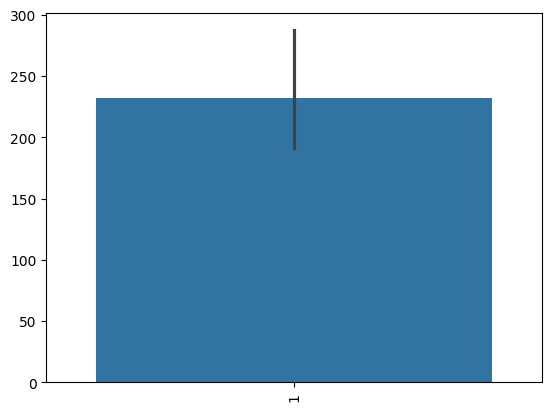

In [122]:

from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30)))
plt.xticks(rotation='vertical')
plt.show()

In [123]:

# Text Vectorization
# using Bag of Words
df.head()


,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## MODEL BUILDING

In [124]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [125]:

X = tfidf.fit_transform(df['transformed_text']).toarray()

In [126]:

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [127]:

#appending the num_character col to X
X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [128]:
X.shape

(5169, 3001)

In [129]:
# Target variable
y = df['target'].values

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# Import models
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

# Initialize models
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


In [130]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8907156673114119
[[800  96]
 [ 17 121]]
0.5576036866359447


In [131]:

mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9738878143133463
[[890   6]
 [ 21 117]]
0.9512195121951219


In [132]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [158]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [159]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision
# This dictionary must exist
clfs = {
    'SVC':                  svc,
    'KNeighbors':           knc,
    'MultinomialNB':        mnb,
    'DecisionTree':         dtc,
    'LogisticRegression':   lrc,
    'RandomForest':         rfc,
    'AdaBoost':             abc,
    'Bagging':              bc,
    'ExtraTrees':           etc,
    'GradientBoosting':     gbdt,
    'XGBoost':              xgb
}

In [160]:
train_classifier(svc,X_train,y_train,X_test,y_test)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.8665377176015474, 0.0)

In [169]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print("For", name)
    print("Accuracy:", current_accuracy)
    print("Precision:", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


For SVC
Accuracy: 0.8665377176015474
Precision: 0.0
For KNeighbors
Accuracy: 0.8858800773694391
Precision: 0.8333333333333334
For MultinomialNB
Accuracy: 0.9738878143133463
Precision: 0.9512195121951219
For DecisionTree
Accuracy: 0.9439071566731141
Precision: 0.8703703703703703
For LogisticRegression
Accuracy: 0.965183752417795
Precision: 0.9553571428571429
For RandomForest
Accuracy: 0.9690522243713733
Precision: 0.9818181818181818


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For AdaBoost
Accuracy: 0.9642166344294004
Precision: 0.9316239316239316
For Bagging
Accuracy: 0.9661508704061895
Precision: 0.8992248062015504
For ExtraTrees
Accuracy: 0.9787234042553191
Precision: 0.9754098360655737
For GradientBoosting
Accuracy: 0.9506769825918762
Precision: 0.9306930693069307
For XGBoost
Accuracy: 0.9700193423597679
Precision: 0.9495798319327731


In [162]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [163]:
performance_df

,Algorithm,Accuracy,Precision
5,RandomForest,0.969052,0.981818
8,ExtraTrees,0.978723,0.975410
4,LogisticRegression,0.965184,0.955357
2,MultinomialNB,0.973888,0.951220
10,XGBoost,0.970019,0.949580
6,AdaBoost,0.964217,0.931624
9,GradientBoosting,0.950677,0.930693
7,Bagging,0.966151,0.899225
3,DecisionTree,0.944874,0.885714
1,KNeighbors,0.885880,0.833333


In [164]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
performance_df1

,Algorithm,variable,value
0,RandomForest,Accuracy,0.969052
1,ExtraTrees,Accuracy,0.978723
2,LogisticRegression,Accuracy,0.965184
3,MultinomialNB,Accuracy,0.973888
4,XGBoost,Accuracy,0.970019
5,AdaBoost,Accuracy,0.964217
6,GradientBoosting,Accuracy,0.950677
7,Bagging,Accuracy,0.966151
8,DecisionTree,Accuracy,0.944874
9,KNeighbors,Accuracy,0.885880


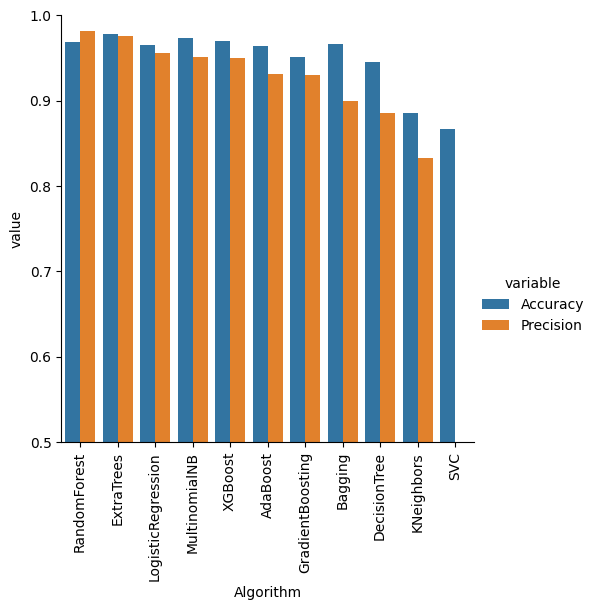

In [165]:

sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [166]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [167]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [168]:
new_df = performance_df.merge(temp_df,on='Algorithm')
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [150]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [151]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,BernoulliNB,0.983559,0.991870,0.983559,0.991870,0.983559,0.991870,0.983559,0.991870
1,MultinomialNB,0.973888,0.951220,0.973888,0.951220,0.973888,0.951220,0.973888,0.951220
2,GaussianNB,0.890716,0.557604,0.890716,0.557604,0.890716,0.557604,0.890716,0.557604


In [152]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [153]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [154]:
VotingClassifier(estimators=[('svm' ,SVC(gamma=1.0, kernel='sigmoid', probability=True)),('nb', MultinomialNB()),('et',
ExtraTreesClassifier(n_estimators=50, random_state=2))],voting='soft')
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))




Accuracy 0.9738878143133463
Precision 1.0


In [155]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [156]:
from sklearn.ensemble import StackingClassifier
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [157]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 0.976
